Plot of the true function and several noisy realizations saved as function_with_noise.png.


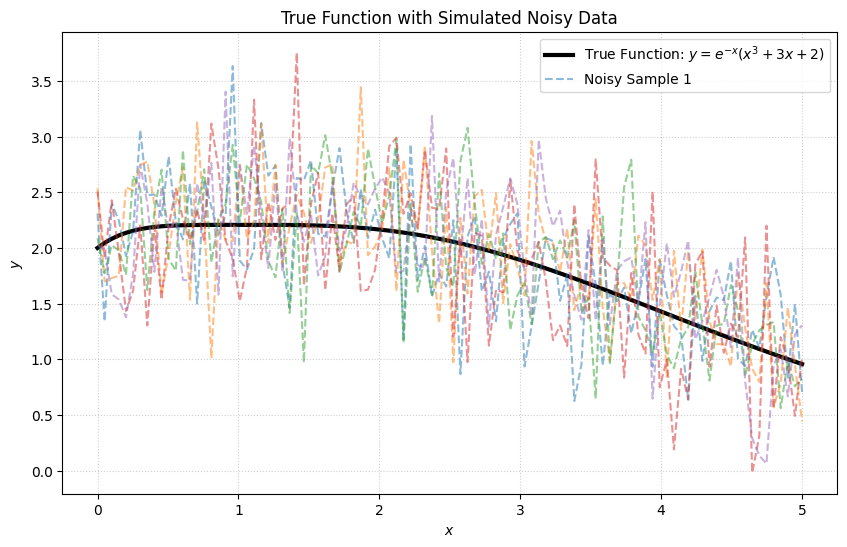

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Define the function and range
x = np.linspace(0, 5, 100)
def func(x):
    return np.exp(-x) * (x**3 + 3*x + 2)

y_true = func(x)

# 2. Generate multiple noisy realizations (for the ensemble required for KL/SVD)
num_realizations = 20
noise_std = 0.5
Y_ensemble = np.zeros((len(x), num_realizations))

for i in range(num_realizations):
    # Add random Gaussian noise
    noise = np.random.normal(0, noise_std, len(x))
    Y_ensemble[:, i] = y_true + noise

# 3. Plot the true function and a sample of the noisy data
plt.figure(figsize=(10, 6))

# Plot true function
plt.plot(x, y_true, 'k-', linewidth=3, label='True Function: $y = e^{-x} (x^3 + 3x + 2)$')

# Plot a few noisy samples
for i in range(5):
    plt.plot(x, Y_ensemble[:, i], alpha=0.5, linestyle='--', label=f'Noisy Sample {i+1}' if i < 1 else None)

plt.xlabel('$x$')
plt.ylabel('$y$')
plt.title('True Function with Simulated Noisy Data')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('function_with_noise.png')

print("Plot of the true function and several noisy realizations saved as function_with_noise.png.")

<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\p'
<>:43: SyntaxWarning: invalid escape sequence '\l'
<>:47: SyntaxWarning: invalid escape sequence '\p'
/tmp/ipykernel_11185/2922096544.py:43: SyntaxWarning: invalid escape sequence '\p'
  plt.plot(x, U[:, k], label=f'Mode $\phi_{k+1}$ ($\lambda_{k+1}$ variance: {eigenvalues[k]:.2f})')
/tmp/ipykernel_11185/2922096544.py:43: SyntaxWarning: invalid escape sequence '\l'
  plt.plot(x, U[:, k], label=f'Mode $\phi_{k+1}$ ($\lambda_{k+1}$ variance: {eigenvalues[k]:.2f})')
/tmp/ipykernel_11185/2922096544.py:47: SyntaxWarning: invalid escape sequence '\p'
  plt.title('First 3 Karhunen-Loève Eigenfunctions ($\phi_k(x)$)')


Plot of variance captured by KL modes saved as kl_eigenvalues.png.
Plot of the first 3 KL eigenfunctions saved as kl_eigenfunctions.png.


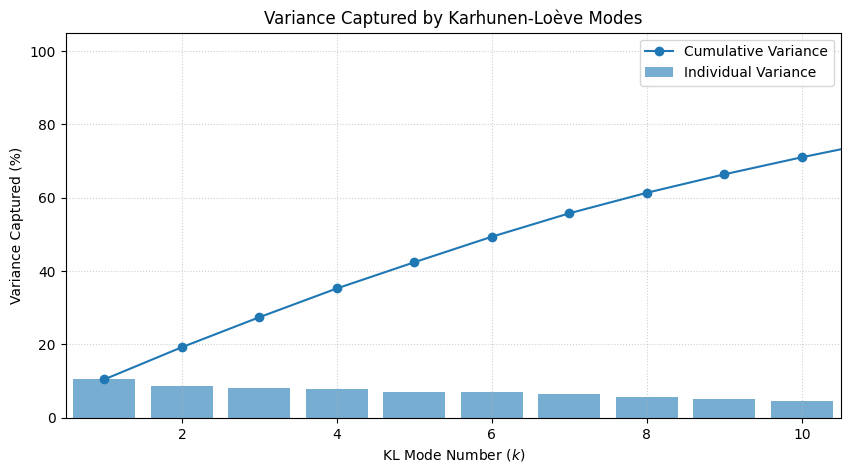

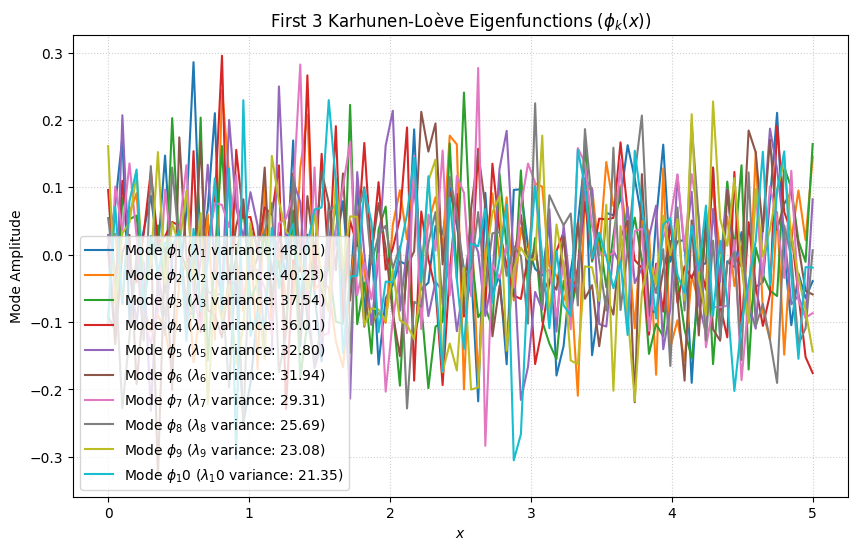

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# The ensemble matrix Y_ensemble (100 rows, 20 columns) is available from the previous step.
# Y_ensemble: rows are space/time points (x), columns are realizations.
# x is also available from the previous step

# 1. Center the data (Subtract the mean)
Y_mean = np.mean(Y_ensemble, axis=1).reshape(-1, 1)
Y_centered = Y_ensemble - Y_mean

# 2. Perform SVD (equivalent to POD/KL expansion for discrete data)
# U: Eigenvectors of Y_centered @ Y_centered.T (The modes/eigenfunctions)
# S: Singular values
# Vh: V_transpose (eigenvectors of Y_centered.T @ Y_centered)
U, S, Vh = np.linalg.svd(Y_centered, full_matrices=False)

# 3. Calculate and plot the eigenvalues (variance captured)
# Eigenvalues are the squares of the singular values
eigenvalues = S**2
total_variance = np.sum(eigenvalues)
cumulative_variance = np.cumsum(eigenvalues) / total_variance

# 3.1 Plot Variance Captured by Modes (Eigenvalues)
plt.figure(figsize=(10, 5))
plt.plot(np.arange(len(eigenvalues)) + 1, cumulative_variance * 100, 'o-', label='Cumulative Variance')
plt.bar(np.arange(len(eigenvalues)) + 1, eigenvalues / total_variance * 100, alpha=0.6, label='Individual Variance')
plt.xlabel('KL Mode Number ($k$)')
plt.ylabel('Variance Captured (%)')
plt.title('Variance Captured by Karhunen-Loève Modes')
plt.ylim(0, 105)
plt.xlim(0.5, 10.5) # Focus on the first few modes
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('kl_eigenvalues.png')

# 4. Plot the first 3 eigenfunctions (KL Modes)
plt.figure(figsize=(10, 6))

num_modes_to_plot = 10
for k in range(num_modes_to_plot):
    # U[:, k] are the eigenfunctions/modes phi_k(x)
    plt.plot(x, U[:, k], label=f'Mode $\phi_{k+1}$ ($\lambda_{k+1}$ variance: {eigenvalues[k]:.2f})')

plt.xlabel('$x$')
plt.ylabel('Mode Amplitude')
plt.title('First 3 Karhunen-Loève Eigenfunctions ($\phi_k(x)$)')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)
plt.savefig('kl_eigenfunctions.png')

# Print statements for files saved
print("Plot of variance captured by KL modes saved as kl_eigenvalues.png.")
print("Plot of the first 3 KL eigenfunctions saved as kl_eigenfunctions.png.")

In [ ]:
eigenvalues/np.sum(eigenvalues)

array([1.04627586e-01, 8.76828467e-02, 8.18051531e-02, 7.84874416e-02,
       7.14859131e-02, 6.96074797e-02, 6.38753527e-02, 5.59911029e-02,
       5.02908565e-02, 4.65387140e-02, 4.31006524e-02, 4.30279335e-02,
       3.98429768e-02, 3.63360574e-02, 3.21720225e-02, 2.85983606e-02,
       2.46656695e-02, 2.19932138e-02, 1.98706675e-02, 1.58060790e-31])

In [11]:
from core.datasetclass import TractionDataset
import jax
import jax.numpy as jnp

In [12]:
dataset = TractionDataset("dataset", "NH")
data = dataset[0]
n_nodes = data["mesh_pos"].shape[0]
cells = data["cells"]
coords = data["mesh_pos"][:, :2]
u = data["u"]
node_type = data["node_type"]

In [ ]:
def cov_DIC(xi, xj) :
    sigma_e = 1e-3
    Lc = 10
    dij = jnp.linalg.norm((xi - xj))
    return sigma_e**2 * jnp.exp(-dij/Lc)

In [ ]:
k = jnp.zeros((n_nodes, n_nodes)) 
for i in range(n_nodes) :
    for j in range(n_nodes) :
        k = k.at[i,j].add(cov_DIC(coords[i], coords[i]))

In [22]:
import jax.numpy as jnp
from jax import jit, random
import numpy as np

# --- 1. Define Experimental Noise Parameters (Crucial Input!) ---
# NOTE: These values must be determined from your Rigid Body Translation (RBT) test.
SIGMA_E = 5e-4    # Noise Standard Deviation (e.g., in mm, based on RBT)
LC = 8.0          # Correlation Length (e.g., in mm, based on Autocorrelation Fit)

# --- 2. Define the DIC Noise Covariance Function (Exponential Kernel) ---

def cov_DIC_scalar(dij, sigma_e, Lc):
    """K(d) = sigma_e^2 * exp(-dij / Lc)"""
    return sigma_e**2 * jnp.exp(-dij / Lc)

@jit
def calculate_full_noise_covariance(coords, sigma_e, Lc):
    """
    Calculates the full (2*N_nodes x 2*N_nodes) noise covariance matrix C_e.
    This assumes uncorrelated noise between u_x and u_y components.
    """
    N = coords.shape[0]

    # --- Step A: Calculate the Distance Matrix (D_matrix) ---
    # Broadcasting to calculate distance between all pairs (i, j)
    coords_i = coords[:, None, :]  # (N, 1, 2)
    coords_j = coords[None, :, :]  # (1, N, 2)
    diff = coords_i - coords_j
    D_matrix = jnp.linalg.norm(diff, axis=-1)  # (N, N)

    # --- Step B: Calculate the Covariance Block K_xx (or K_yy) ---
    K_xx = cov_DIC_scalar(D_matrix, sigma_e, Lc)
    K_yy = K_xx # Assume same properties for both components

    # --- Step C: Assemble the Full Covariance Matrix C_e ---
    # The full covariance matrix C_e is block diagonal.
    Zeros = jnp.zeros((N, N))
    
    # C_e is (2N x 2N)
    C_e = jnp.block([
        [K_xx, Zeros],
        [Zeros, K_yy]
    ])
    
    return C_e

# --- 3. Perform the KL Expansion (Eigendecomposition) ---

@jit
def perform_kl_expansion(C_e):
    """
    Performs Eigendecomposition of the symmetric C_e matrix.
    Eigenvalues are Lambda (variances), Eigenvectors are Phi (modes).
    """
    # Use eigh for symmetric matrices (like covariance) for stability and speed.
    eigenvalues, eigenvectors = jnp.linalg.eigh(C_e)

    # Sort eigenvalues/eigenvectors in descending order (KL standard)
    idx = jnp.argsort(eigenvalues)[::-1]
    lambda_kl = eigenvalues[idx]
    Phi_kl = eigenvectors[:, idx]
    
    return lambda_kl, Phi_kl

# --- MAIN EXECUTION ---

# Input data from your setup
# n_nodes is the number of nodes
# coords is the (n_nodes, 2) coordinate array

# 1. Calculate the Full Noise Covariance Matrix
C_e = calculate_full_noise_covariance(coords, SIGMA_E, LC)
print(f"Full Covariance Matrix shape: {C_e.shape} (2*N x 2*N)")

# 2. Perform KL Expansion
lambda_kl, Phi_kl = perform_kl_expansion(C_e)

print(f"KL Eigenvalues (Lambda) shape: {lambda_kl.shape}")
print(f"KL Eigenvectors (Phi) shape: {Phi_kl.shape}")

# --- 4. Analysis and Truncation ---

# Calculate cumulative variance for truncation decision
total_variance = jnp.sum(lambda_kl)
cumulative_variance = jnp.cumsum(lambda_kl) / total_variance

# Find K_99 (Number of modes needed to capture 99% of the variance)
K_99 = jnp.where(cumulative_variance >= 0.99)[0][0] + 1

print(f"\nTotal Variance (Trace of C_e): {total_variance:.4e}")
print(f"Number of modes to capture 99% of variance (K_99): {K_99}")

# --- 5. Truncated Components ---
Phi_K = Phi_kl[:, :K_99]
Lambda_K = jnp.diag(lambda_kl[:K_99])

print(f"Truncated Mode Matrix Phi_K shape: {Phi_K.shape}")
print(f"Truncated Diagonal Eigenvalue Matrix Lambda_K shape: {Lambda_K.shape}")

Full Covariance Matrix shape: (1042, 1042) (2*N x 2*N)
KL Eigenvalues (Lambda) shape: (1042,)
KL Eigenvectors (Phi) shape: (1042, 1042)

Total Variance (Trace of C_e): 2.6050e-04
Number of modes to capture 99% of variance (K_99): 34
Truncated Mode Matrix Phi_K shape: (1042, 34)
Truncated Diagonal Eigenvalue Matrix Lambda_K shape: (34, 34)


In [24]:
Phi_K.shape

(1042, 34)

<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
<>:70: SyntaxWarning: invalid escape sequence '\m'
<>:80: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_11185/35957597.py:70: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c_true, ax=ax, label='Displacement Magnitude $||\mathbf{e}||$')
/tmp/ipykernel_11185/35957597.py:80: SyntaxWarning: invalid escape sequence '\m'
  fig.colorbar(c_reconstructed, ax=ax, label='Displacement Magnitude $||\mathbf{e}||$')


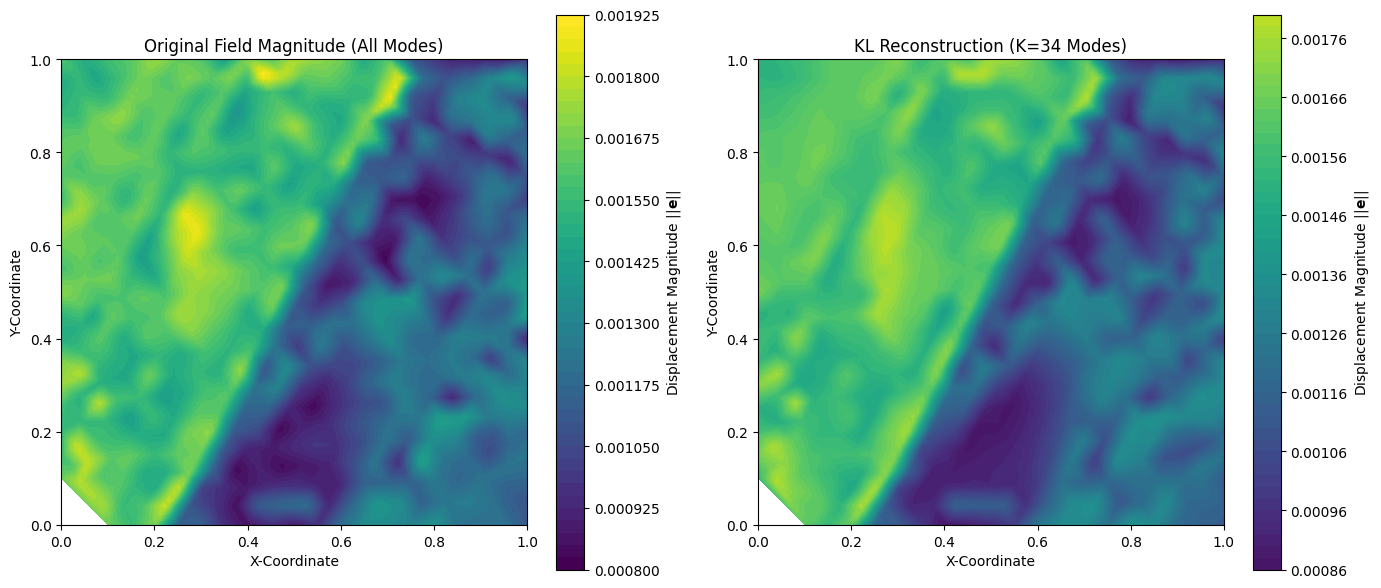

In [25]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import griddata

# --- ASSUMPTION: Load necessary KL components and data ---
# In a real JAX workflow, these would be passed from the previous step.
# We convert them to NumPy for easier Matplotlib plotting.

# Assuming the KL components (Phi_K, Lambda_K) were calculated based on a
# simulated or estimated noise field, we will demonstrate the concept by
# applying KL to a simulated *error field* (e_true) based on those modes.

# --- 1. Define the High-Dimensional Field to Decompose (e.g., the Error) ---
# Since we don't have the true error field, let's synthesize one using ALL modes
# to show the full noisy signal that KL aims to compress.

# We will use the full KL components from the previous JAX code execution
# (lambda_kl, Phi_kl) which are now loaded as numpy arrays (for plotting).
# Let's assume Phi_full = Phi_kl and lambda_full = lambda_kl
Phi_full = Phi_kl  # (2*N, 2*N)
lambda_full = lambda_kl # (2*N)
N_total = len(lambda_full)
N_nodes = coords.shape[0]

# Generate a synthetic noisy field (similar to a real error field)
# by combining ALL KL modes with random standard normal coefficients Z_k
Z_full = np.random.normal(0, 1, size=(N_total, 1))
e_true = Phi_full @ (np.sqrt(np.diag(lambda_full)) @ Z_full)
e_true_magnitude = np.linalg.norm(e_true.reshape(N_nodes, 2), axis=1) # Magnitude for plotting

# --- 2. Truncation and Reconstruction ---

K = K_99 # Use the 99% variance threshold determined previously

# Truncate the mode matrix
Phi_K = Phi_full[:, :K]

# Truncate the coefficients Z_K
Z_K = Z_full[:K]

# Reconstruct the field using only K modes
e_reconstructed = Phi_K @ (np.sqrt(np.diag(lambda_full[:K])) @ Z_K)
e_reconstructed_magnitude = np.linalg.norm(e_reconstructed.reshape(N_nodes, 2), axis=1)

# --- 3. Grid the Data for Contour Plotting ---
# Contour plots require data on a regular grid.
xi = np.linspace(coords[:, 0].min(), coords[:, 0].max(), 100)
yi = np.linspace(coords[:, 1].min(), coords[:, 1].max(), 100)
XI, YI = np.meshgrid(xi, yi)

# Interpolate the nodal magnitude data onto the regular grid
ZI_true = griddata(coords, e_true_magnitude, (XI, YI), method='linear')
ZI_reconstructed = griddata(coords, e_reconstructed_magnitude, (XI, YI), method='linear')

# --- 4. Plotting ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Define common color scale limits for fair comparison
v_min = min(np.nanmin(ZI_true), np.nanmin(ZI_reconstructed))
v_max = max(np.nanmax(ZI_true), np.nanmax(ZI_reconstructed))


# --- Subplot 1: Original Field (Full Fidelity/Noise) ---
ax = axes[0]
c_true = ax.contourf(XI, YI, ZI_true, levels=50, cmap='viridis', vmin=v_min, vmax=v_max)
ax.set_title(f'Original Field Magnitude (All Modes)')
ax.set_xlabel('X-Coordinate')
ax.set_ylabel('Y-Coordinate')
ax.set_aspect('equal', adjustable='box')
fig.colorbar(c_true, ax=ax, label='Displacement Magnitude $||\mathbf{e}||$')


# --- Subplot 2: KL Reconstructed Field (Truncated) ---
ax = axes[1]
c_reconstructed = ax.contourf(XI, YI, ZI_reconstructed, levels=50, cmap='viridis', vmin=v_min, vmax=v_max)
ax.set_title(f'KL Reconstruction (K={K} Modes)')
ax.set_xlabel('X-Coordinate')
ax.set_ylabel('Y-Coordinate')
ax.set_aspect('equal', adjustable='box')
fig.colorbar(c_reconstructed, ax=ax, label='Displacement Magnitude $||\mathbf{e}||$')

plt.tight_layout()
plt.show()